# Spatial Omics Analysis

Inspried by {cite:p}`MarrahiNipmap2023,turosChrysalisDecodingTissue2024,cell2location`, we showcase here how archetypal analysis can be used to model the diversity in spatial niches.

## Packages

In [1]:
from pathlib import Path
import requests
import zipfile

import scanpy as sc
import pandas as pd
import numpy as np
import squidpy as sq
import plotnine as pn
import decoupler as dc

import partipy as pt

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Data

Here we will use 10X Xenium data from post-mortem spinal cord samples from chronic acitve and chronic inactive multiple sclerosis lesions as well as control samples {cite:p}`Kukanja2024`. Do we find spatial niches that are enriched in multiple sclerosis samples?

In [2]:
data_folder = Path(".") / "data"
data_folder.mkdir(parents=True, exist_ok=True)

zip_path = data_folder / "MS_xenium_data_v5_with_images_tmap.h5ad.zip"
file_path = data_folder / "MS_xenium_data_v5_with_images_tmap.h5ad"

if file_path.exists():
    print(f"Loading existing data from {file_path}")
    adata = sc.read_h5ad(file_path)
elif zip_path.exists():
    print(f"Zip file found at {zip_path}. Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_folder)
    print(f"File extracted to {file_path}")
    adata = sc.read_h5ad(file_path)
else:
    url = "https://zenodo.org/records/8037425/files/MS_xenium_data_v5_with_images_tmap.h5ad.zip?download=1"
    print(f"File not found. Downloading from {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Raise an error for bad HTTP status codes
    with open(zip_path, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
    print(f"File downloaded to {zip_path}")
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_folder)
    print(f"File extracted to {file_path}")
    adata = sc.read_h5ad(file_path)
adata

Loading existing data from data/MS_xenium_data_v5_with_images_tmap.h5ad


AnnData object with n_obs × n_vars = 660801 × 266
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'n_counts', 'batch', 'type', 'type_spec', 'leiden_0.1', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'project', 'rotate', 'flip', 'Level0', 'reclustered_Level0', 'x_rotated_2', 'y_rotated_2', 'sex', 'age', 'y_rotated_mod', 'x_rotated_mod', 'Level1', 'Level2', 'Level3', 'compartment', 'compartment_2', 'compartment_2_colors', 'region_area', 'Level1_5', 'library_id'
    uns: 'Level0_colors', 'Level0_wilcoxon', 'Level1_5_colors', 'Level1_5_wilcoxon', 'Level1_colors', 'Level1_wilcoxon', 'Level2_colors', 'Level2_wilcoxon', 'Level3_colors', 'Level3_wilcoxon', 'age_colors', 'compartment_2_colors', 'compartment_colors', 'dendrogram_Level1_5', 'leiden', 'leiden_0.1_colors', 'leiden_0.5_colors', 'leiden_1.5_colors', 'leiden_1_colors', '

We will remove cells with fewer that 20 transcripts.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 50 rows containing non-finite values.


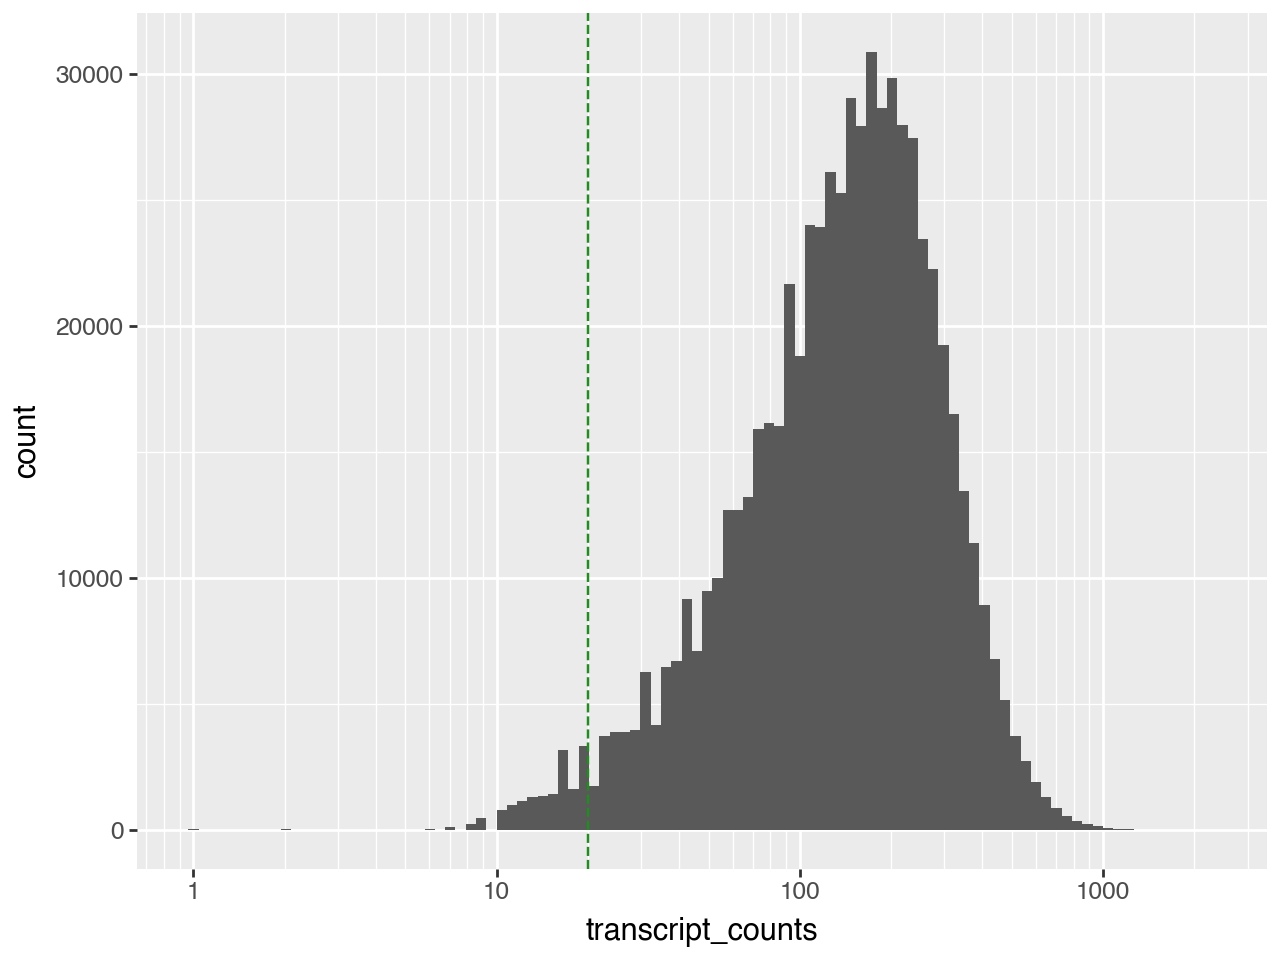

In [3]:
(pn.ggplot(adata.obs) 
 + pn.geom_histogram(pn.aes(x="transcript_counts"), bins=100) 
 + pn.geom_vline(xintercept=20, color="forestgreen", linetype="dashed")
 + pn.scale_x_log10())

We will use scanpy for basic preprocessing of the data.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


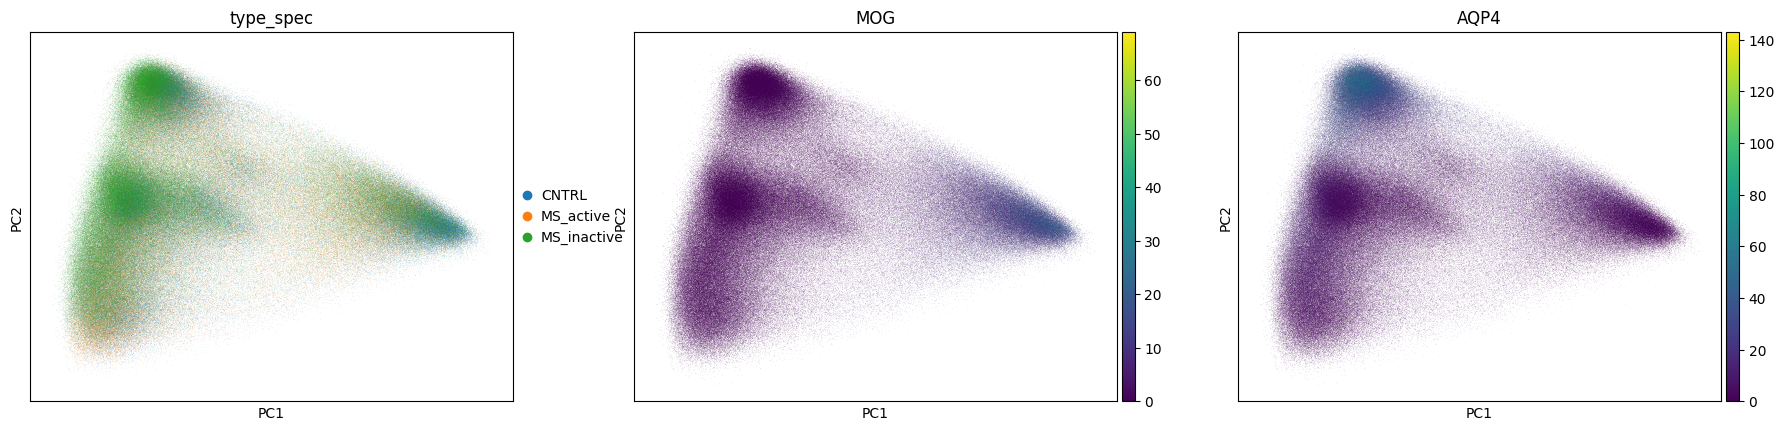

In [22]:
adata = adata[adata.obs["transcript_counts"] >= 20, :].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10, copy=True) # save this for later
sc.pl.pca_scatter(adata, color=["type_spec", "MOG", "AQP4"])

To get a niche-level representation of the data we will first spatially smooth the PCA coordinates using Delauny triangulation to define the neighbors of each cell.

In [5]:
sq.gr.spatial_neighbors(adata, 
                        spatial_key="spatial",
                        library_key="library_id",
                        coord_type="generic",
                        delaunay=True, 
                        set_diag=True, 
                        radius=[0, 80])

bandwidth = float(np.quantile(adata.obsp["spatial_distances"].data, 0.5))
adata.obsp["spatial_weights"] = adata.obsp["spatial_distances"].copy()
adata.obsp["spatial_weights"].data = np.exp(-adata.obsp["spatial_distances"].data**2 / (2*bandwidth**2))
adata.obsp["spatial_weights"].setdiag(1.0)
adata.obsm["X_pca_spatial"] = adata.obsp["spatial_weights"] @ adata.obsm["X_pca"]

To get a feeling for the spatial weights, we will visualize the weights for a single cell.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 129411 rows containing missing values.


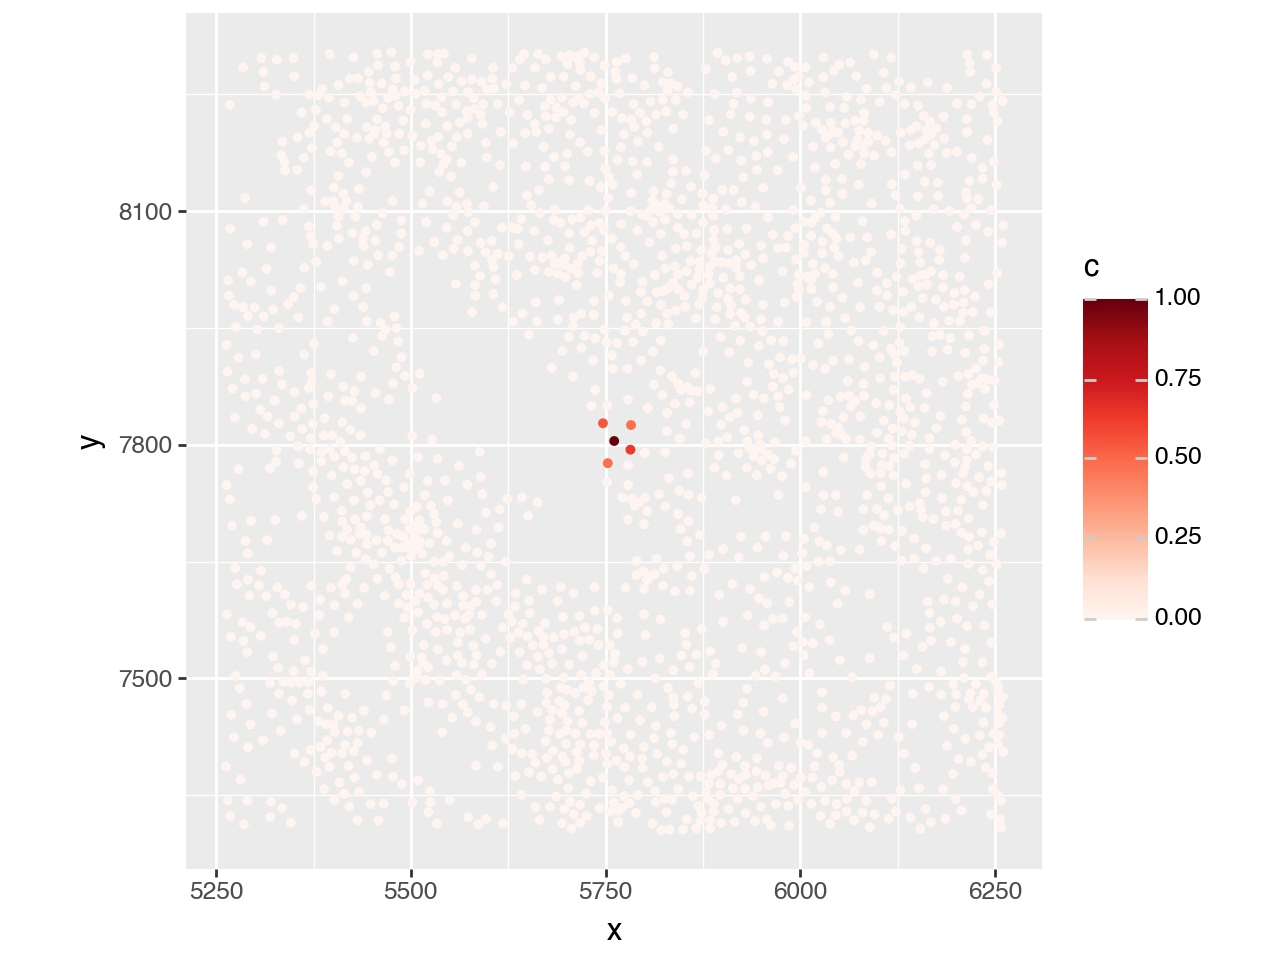

In [6]:
adata_smp = adata[adata.obs["library_id"]=="Active-C_2013-019", :].copy()
idx = 2_000
adata_smp.obs[f"weights_{idx}"] = adata_smp.obsp["spatial_weights"][idx, :].toarray().flatten()

plot_df = pd.DataFrame({
    "x": adata_smp.obsm["spatial"][:, 0],
    "y": adata_smp.obsm["spatial"][:, 1],
    "c": adata_smp.obs[f"weights_{idx}"]
})
plot_df

x_coord = adata_smp.obsm["spatial"][idx, 0]
y_coord = adata_smp.obsm["spatial"][idx, 1]

(pn.ggplot(plot_df) 
 + pn.geom_point(pn.aes(x="x", y="y", color="c"), size=1.0) 
 + pn.lims(x=[x_coord-500, x_coord+500], y=[y_coord-500, y_coord+500]) 
 + pn.scale_color_cmap(cmap_name="Reds")
 + pn.coord_equal())

To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. The plot indicates that the gain in explained variance becomes negligible beyond the sixth principal component.

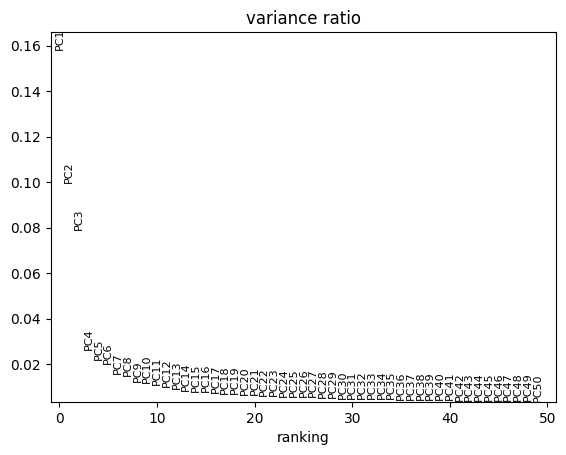

In [7]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

First we need to determine the number of archetypes. Since we have 600,000 cells here, we will use a coreset fraction of 3% specified by `coreset_fraction=0.03` and `coreset_algorithm="standard"`. Additionally, we need to specify that we want to use the spatially smoothed PCA coordinates, `obsm_key="X_pca_spatial"`.

In [8]:
pt.set_obsm(adata=adata, obsm_key="X_pca_spatial", n_dimensions=6)

We start - as always - by computing the statistics used to determine the number of archetypes.

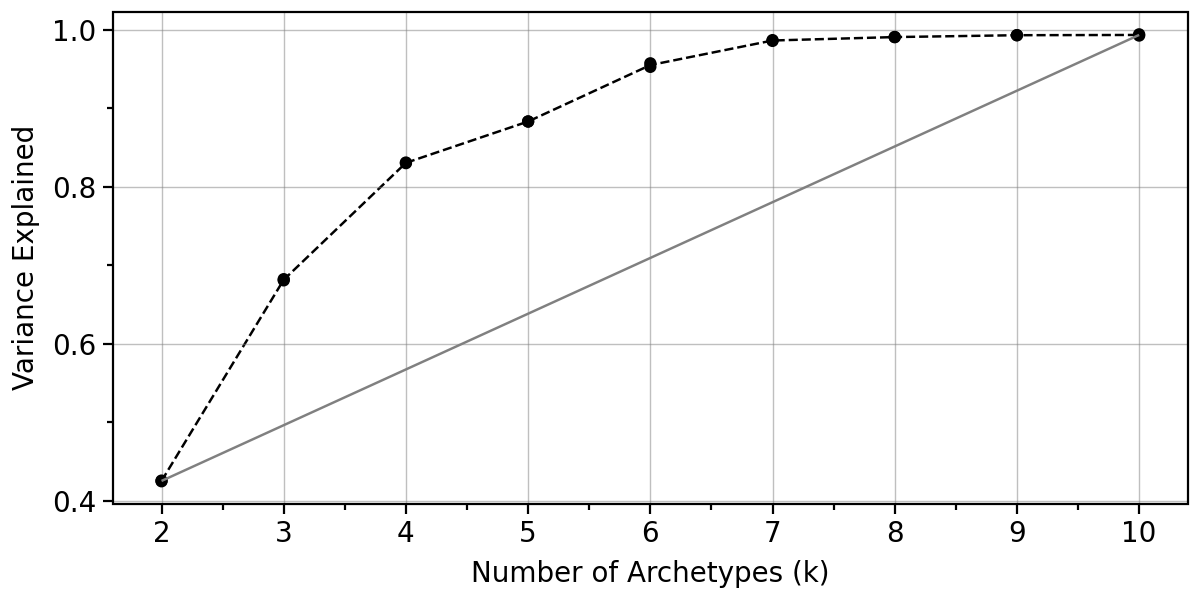

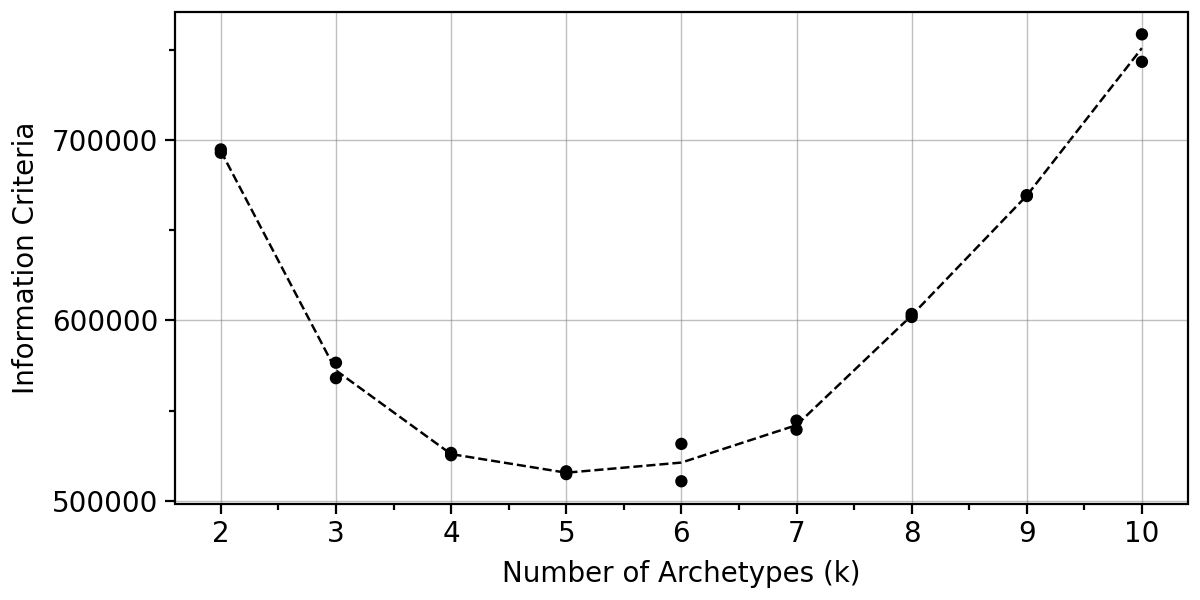

In [9]:
# takes ~3.5 minutes on my macbook
pt.compute_selection_metrics(adata=adata, 
                             min_k=2, max_k=10, 
                             coreset_algorithm="standard",
                             coreset_fraction=0.03, 
                             n_restarts=2)
pt.plot_var_explained(adata).show()
pt.plot_IC(adata).show()

Let us also look at the boostrap variance when using 4-6 archetypes.

In [10]:
# takes ~3.5 minutes on my macbook
pt.compute_bootstrap_variance(adata=adata, 
                              n_bootstrap=20, 
                              n_archetypes_list=[4, 5, 6],
                              coreset_algorithm="standard",
                              coreset_fraction=0.03)

Given the observed high positional variance of one archetype in the 5-archetype solution, our results indicate that either 4 or 6 archetypes should be used. Here we will proceed with 6 archetypes.

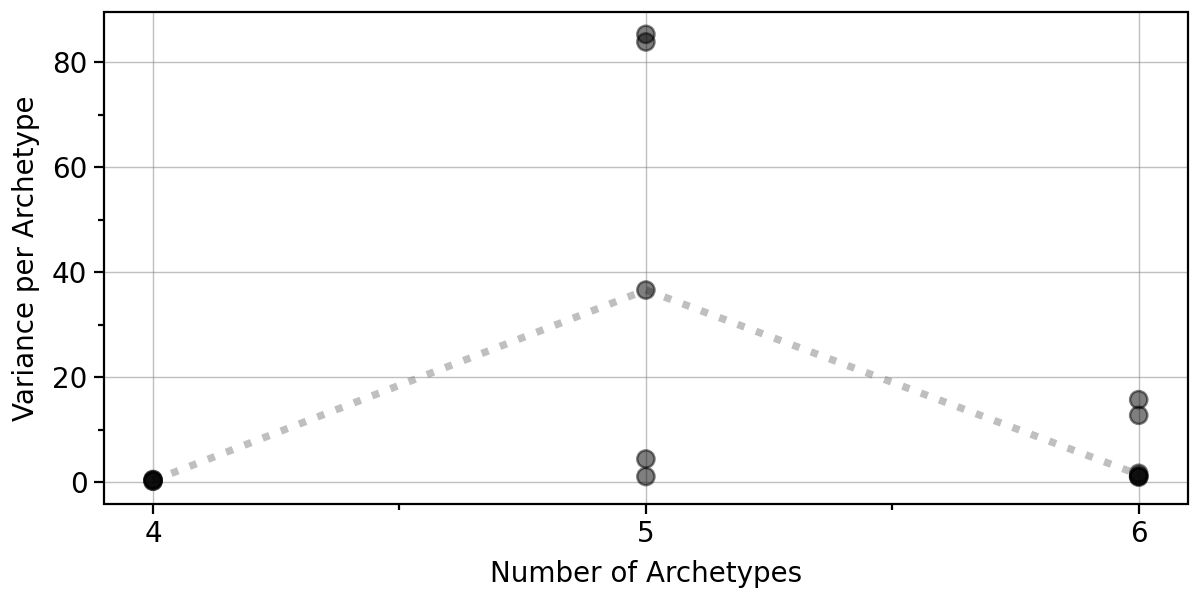

In [11]:
pt.plot_bootstrap_variance(adata)

We can also visualize the boostrap results for 6 archetypes in 2D.

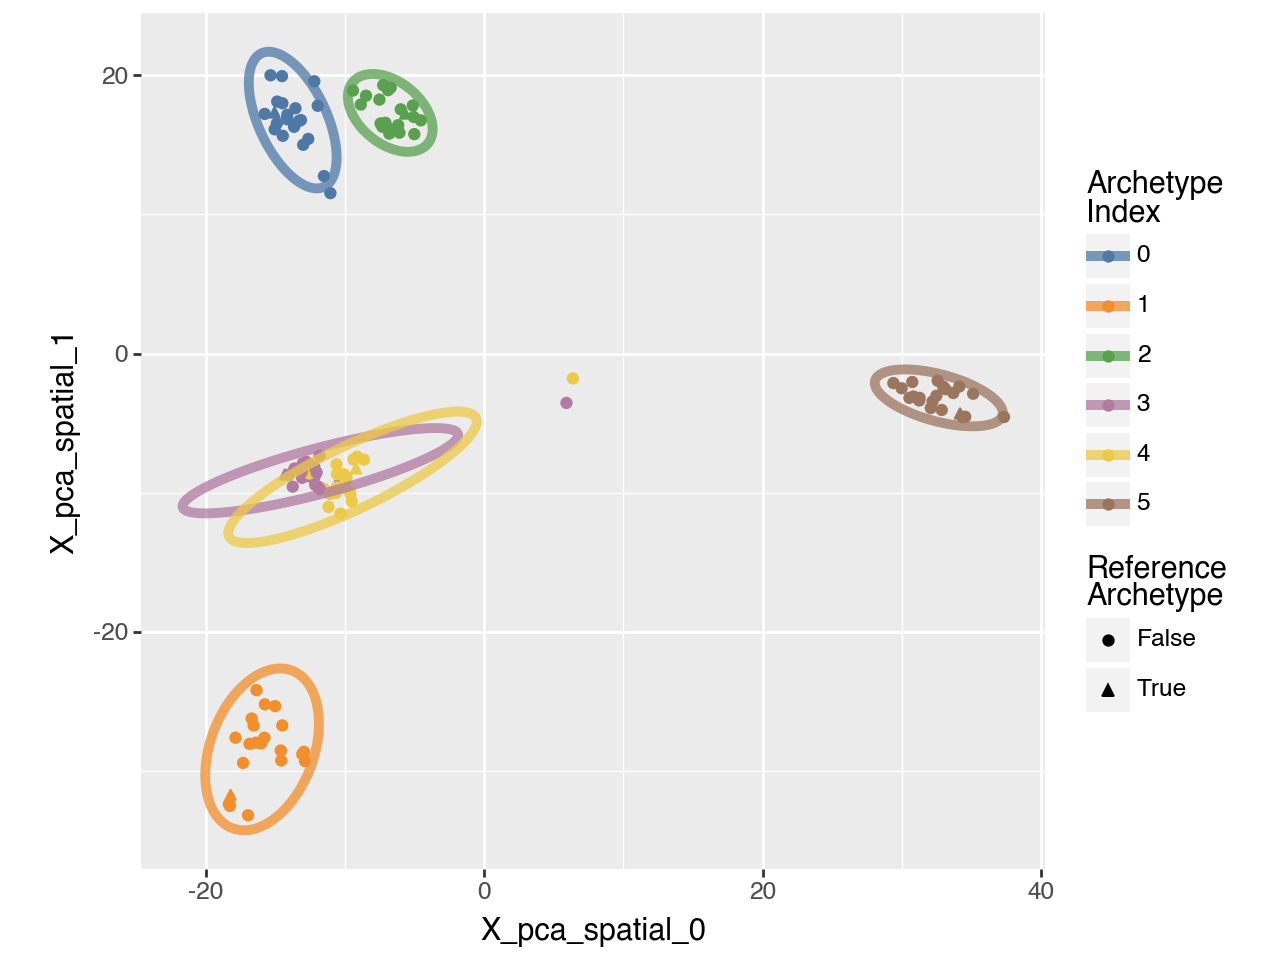

In [12]:
pt.plot_bootstrap_2D(adata, n_archetypes=6)

In [13]:
pt.compute_archetypes(adata, 
                      n_archetypes=6, 
                      coreset_algorithm="standard", 
                      coreset_fraction = 0.03, 
                      archetypes_only=False)

We also visualize the archetypes and their bootstrap-derived confidence contours in a 2D PC plot alongside all individual data points (i.e. cells).

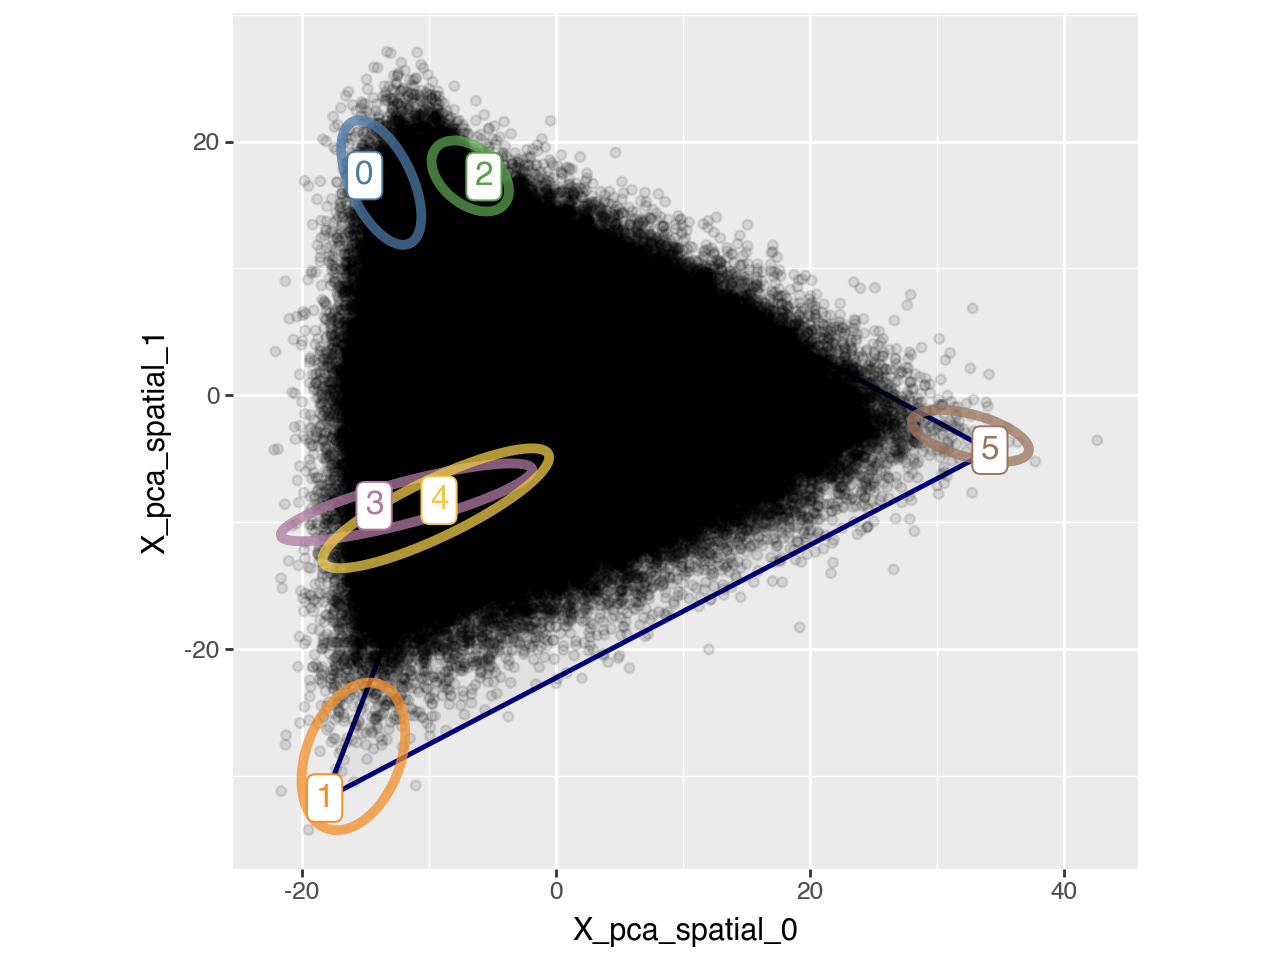

In [14]:
pt.plot_archetypes_2D(adata, show_contours=True, alpha=0.1, dimensions=[0, 1])

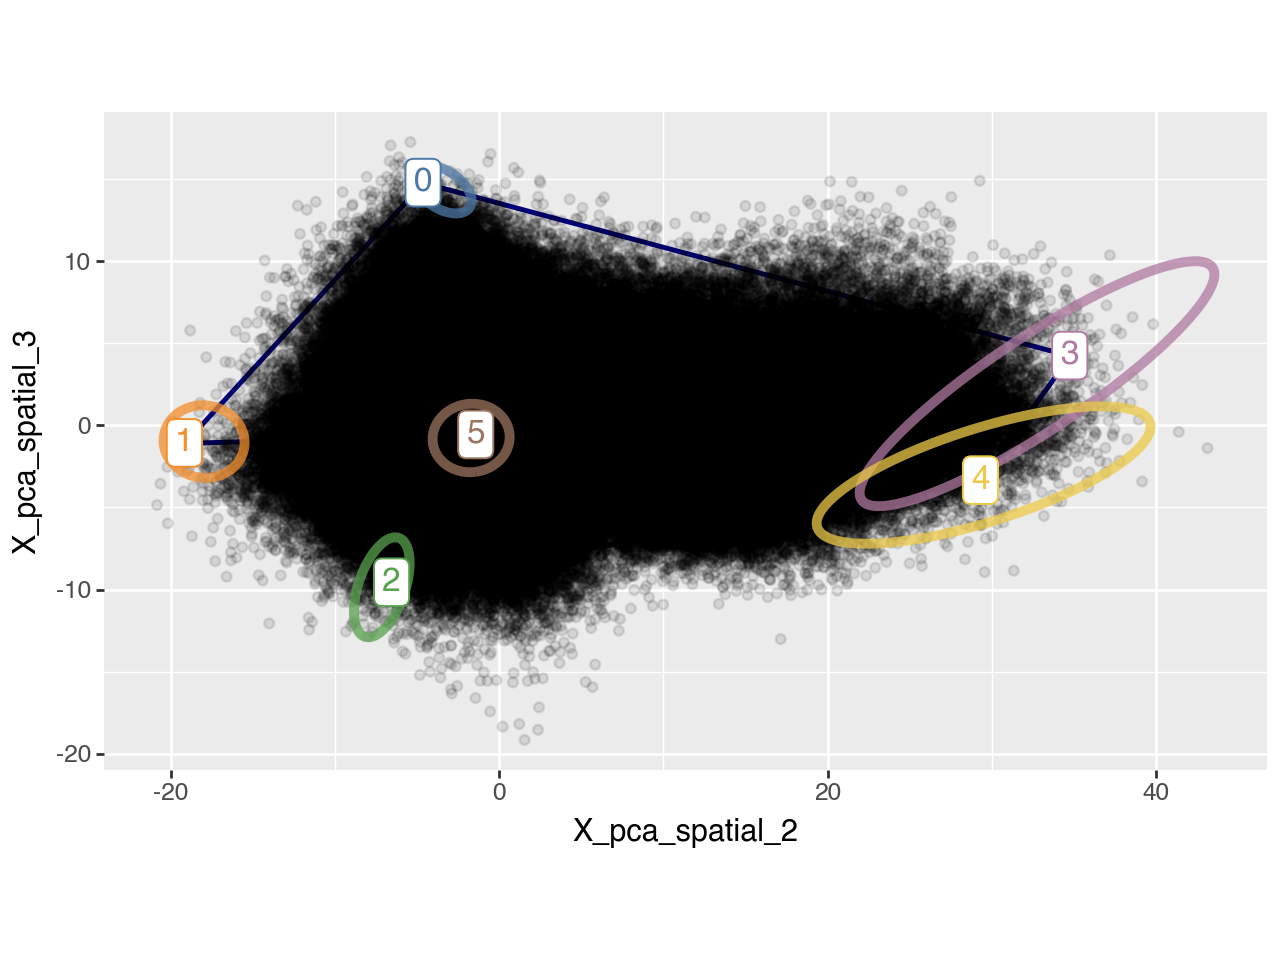

In [15]:
pt.plot_archetypes_2D(adata, show_contours=True, alpha=0.1, dimensions=[2, 3])

Now let's find out if we have archetypes that are enriched in control or multiple sclerosis samples. Interestingly we do not find any archetype that is unique to a condtion. However, we find archetypes that are mildly enriched in certain conditions.

Applied length scale is 17.64.


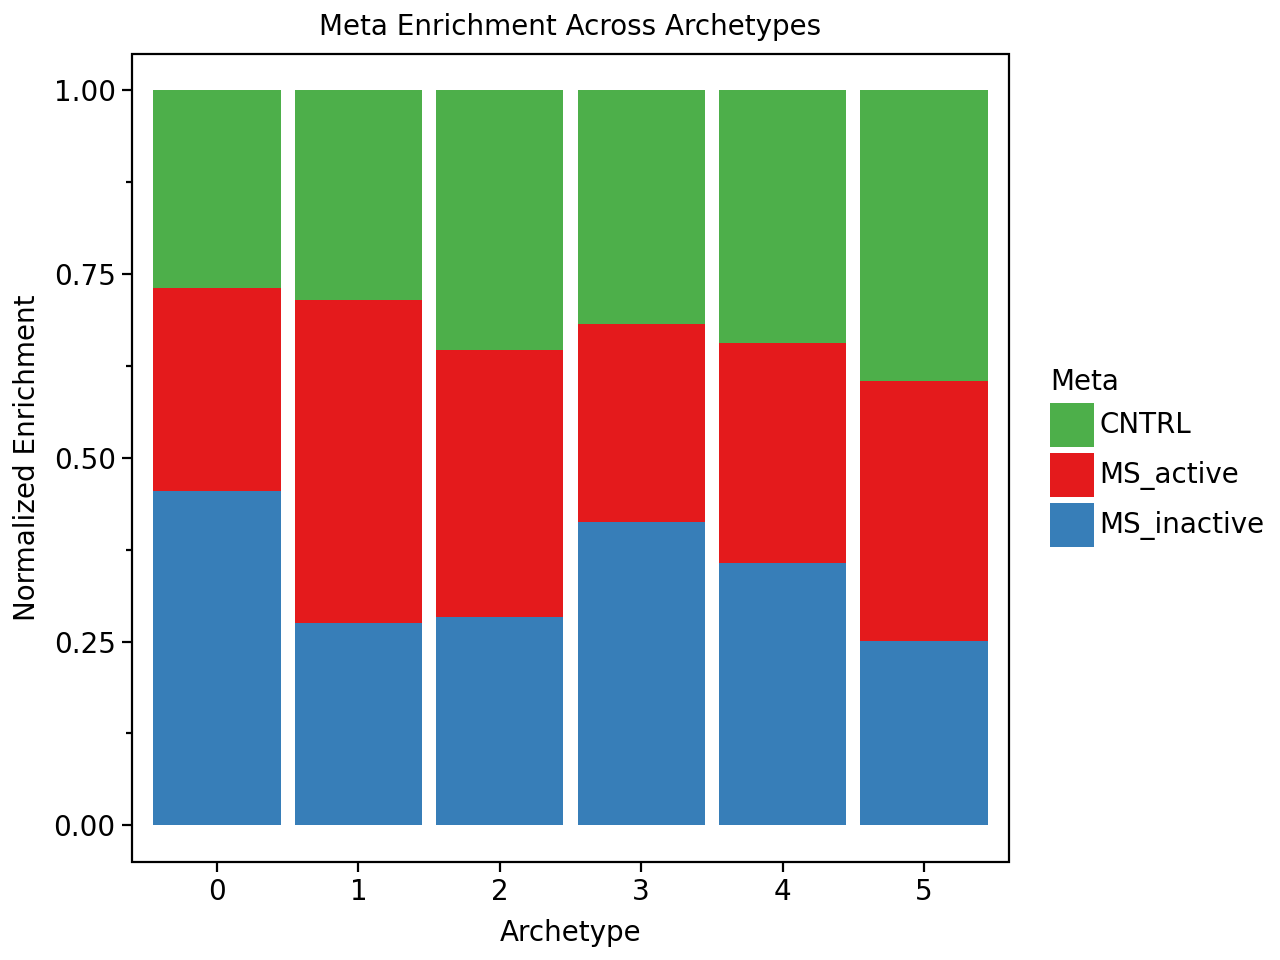

In [16]:
pt.compute_archetype_weights(adata=adata, mode="automatic")

condition_enrichment = pt.compute_meta_enrichment(adata, meta_col="type_spec")

condition_colors = {
    'CNTRL': '#4daf4a',       # green for control
    'MS_active': '#e41a1c',   # red for active MS
    'MS_inactive': '#377eb8'  # blue for inactive MS
}

pt.barplot_meta_enrichment(condition_enrichment, color_map=condition_colors)

We will also check which cell types are enriched in the different niches defined by the archetypes.

And we see for example that one archetype is enriched for damaged-associated astrocytes ("Astrocytes_DA"), and that this archetype is also enriched in MS_inactive samples. We also see that the white matter archetypes (i.e. the archetype with a lot of oligodendrocytes (OLG)) is enriched in the control samples.

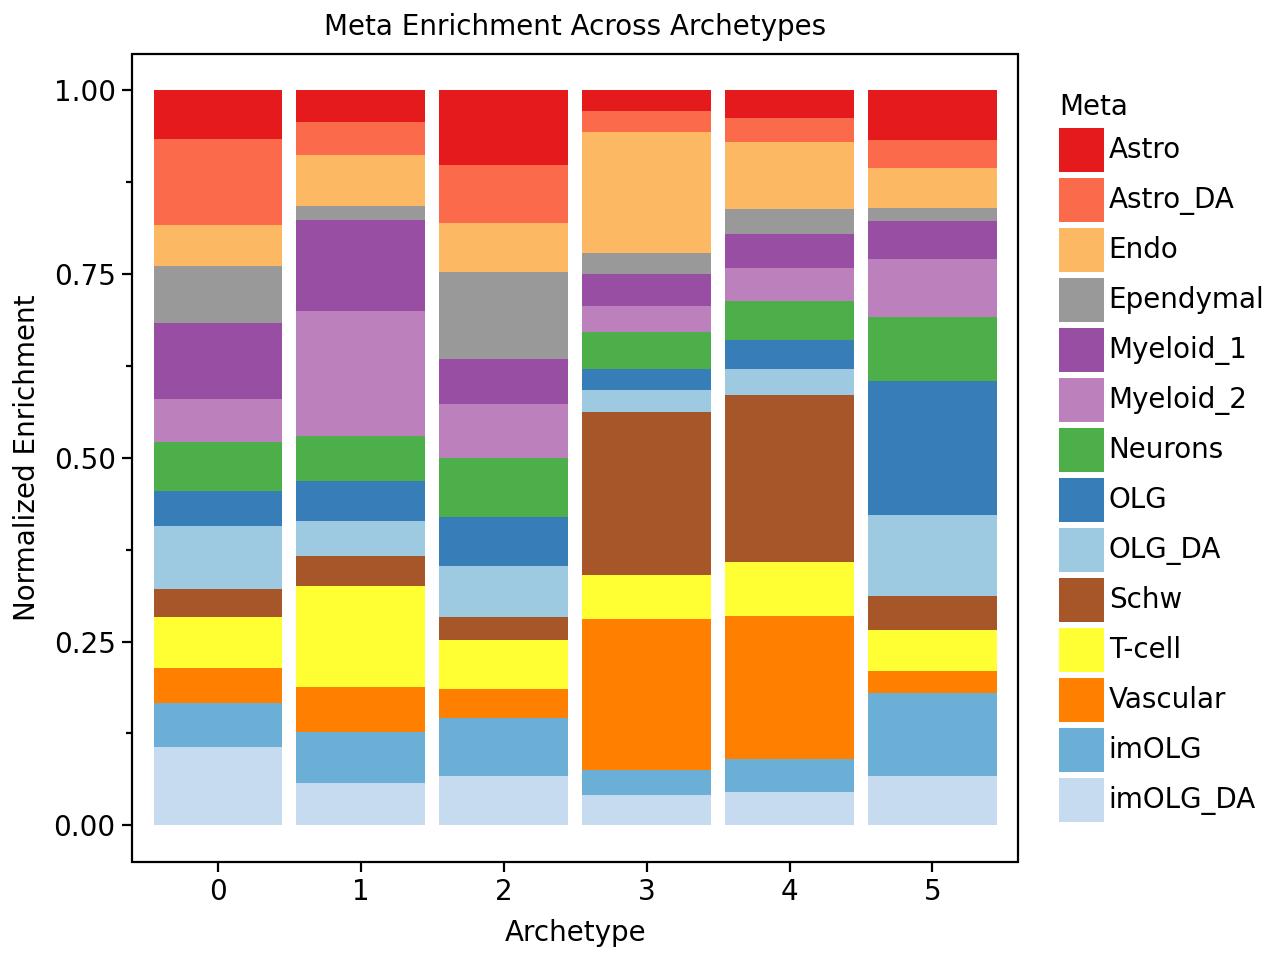

In [17]:
celltype_enrichment = pt.compute_meta_enrichment(adata, meta_col="Level1_5")

celltype_colors = {
    # Oligodendrocyte lineage
    'OLG': '#377eb8',
    'imOLG': '#6baed6',
    'OLG_DA': '#9ecae1',
    'imOLG_DA': '#c6dbef',

    # Astrocytes
    'Astro': '#e41a1c',
    'Astro_DA': '#fb6a4a',

    # Myeloid lineage
    'Myeloid_1': '#984ea3',
    'Myeloid_2': '#bc80bd',

    # Vascular / Endothelial
    'Vascular': '#ff7f00',
    'Endo': '#fdb863',

    # Neurons
    'Neurons': '#4daf4a',

    # Schwann cells
    'Schw': '#a65628',

    # Ependymal cells
    'Ependymal': '#999999',

    # T-cells
    'T-cell': '#ffff33',
}

pt.barplot_meta_enrichment(celltype_enrichment, color_map=celltype_colors)

Apart from looking at cell type enrichement we can also directly look at the genes that are associated with each archetype. And we see that the archetype enriched in chronic inactive samples exhibits high expression of SERPINA3, HILPDA, and TGFB2.

In [18]:
archetype_expression = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

arch_idx_ms_inactive = condition_enrichment["MS_inactive"].idxmax()
arch_idx_ms_active = condition_enrichment["MS_active"].idxmax()

archetype_expression.T.sort_values(arch_idx_ms_inactive, ascending=False).head(10).round(2)

,0,1,2,3,4,5
SERPINA3,51343.94,-7523.21,7930.14,-6864.13,-12160.26,-32726.48
HILPDA,45489.00,-8596.32,-4552.23,2666.61,-8853.64,-26153.42
AQP4,43969.71,-5814.88,51553.31,-24361.85,-44738.67,-20607.62
MGST1,40558.87,-6700.02,26254.09,-13915.00,-22165.99,-24031.95
TGFB2,39079.07,-4877.68,14609.17,-9004.67,-19079.27,-20726.61
PTPRZ1,32103.70,-6958.35,33979.72,-15461.48,-29518.74,-14144.85
APOE,29468.84,11719.63,35371.80,-19328.17,-37987.26,-19244.83
DNER,26088.09,-10571.86,35787.33,-21707.78,-41746.12,12150.34
SOX9,25402.44,-9486.32,34279.58,-11452.17,-17828.87,-20914.65
TRIL,25096.04,-7466.01,39980.18,-13946.29,-27447.26,-16216.65


Instead of looking at the genes directly, we can also perform pathway enrichment analysis, which reveals that the archetype enriched in chronic inactive samples exhibits high levels of hypoxia. However, since only 266 were profiled here, prior knowledge enrichment analysis is not very reliable here!

In [19]:
net = dc.op.progeny()

acts_ulm_est, acts_ulm_est_p = dc.mt.ulm(data=archetype_expression,
                                         net=net,
                                         verbose=False)

top_processes = pt.extract_enriched_processes(est=acts_ulm_est, 
                                              pval=acts_ulm_est_p, 
                                              order="desc", 
                                              n=3,
                                              p_threshold=0.10)

top_processes[arch_idx_ms_inactive]

,Process,0,1,2,3,4,5,specificity
0,Hypoxia,3.070794,-0.369261,-1.802874,2.422160,0.774676,-2.195919,0.648634
1,TNFa,2.525195,0.816637,-1.049080,-0.098019,0.264685,-1.184924,1.708558


Finally, since we have spatial data let's check where this archetype located in space. And we see that this niche is rather located at the edge of the spine.

Applied length scale is 17.64.


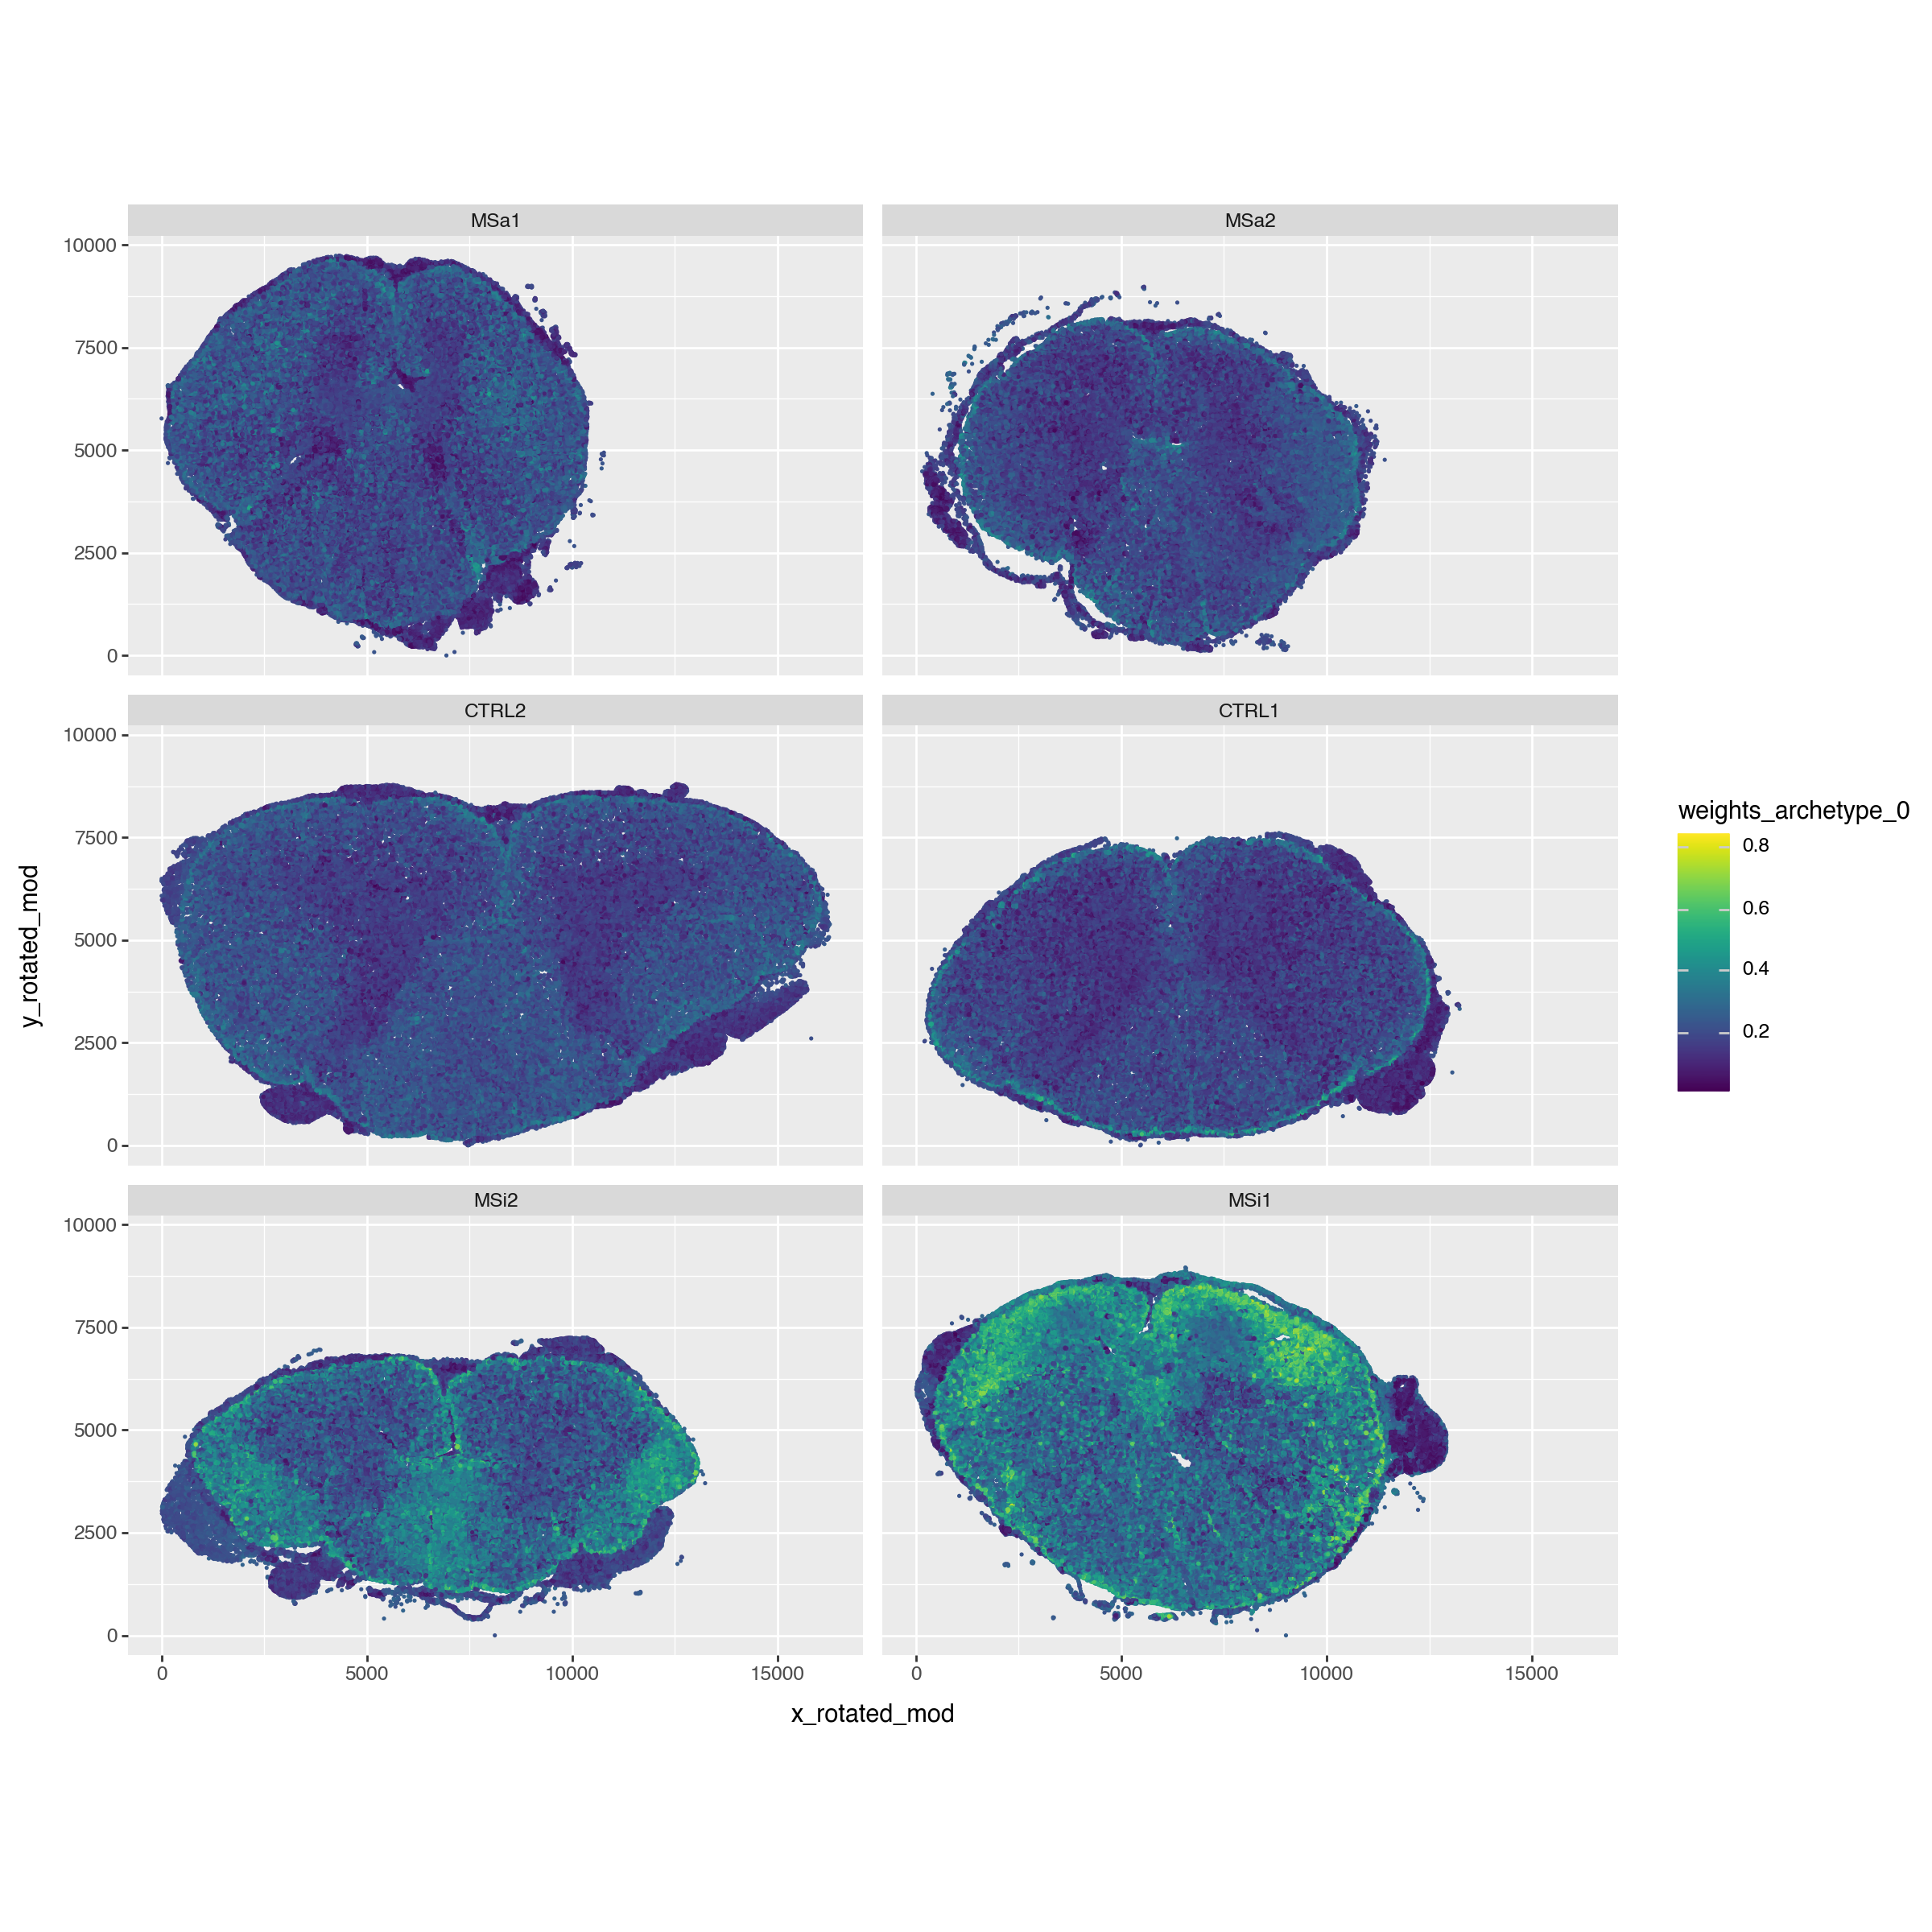

In [20]:
pt.compute_archetype_weights(adata=adata, mode="automatic")

adata.obs[f"weights_archetype_{arch_idx_ms_inactive}"] = adata.obsm["cell_weights"][:, arch_idx_ms_inactive].copy()

p = (pn.ggplot(adata.obs) 
     + pn.geom_point(pn.aes(x="x_rotated_mod", y="y_rotated_mod", color=f"weights_archetype_{arch_idx_ms_inactive}"), size=0.05) 
     + pn.facet_wrap(facets="sample_id", ncol=2) 
     + pn.coord_equal()
     + pn.theme(figure_size=(12, 12))
     )
p

## Session Info

In [21]:
import session_info2
print(session_info2.session_info(dependencies=True))

plotnine	0.14.5
pandas	2.2.3
requests	2.32.3
scanpy	1.11.2
numpy	2.2.6
squidpy	1.6.5
decoupler	2.0.6
partipy	0.0.1
anndata	0.11.4
----	----
executing	2.2.0
zarr	2.18.7
pyct	0.5.0
prompt_toolkit	3.0.51
ipywidgets	8.1.7
stack-data	0.6.3
attrs	25.3.0
tqdm	4.67.1
geopandas	1.0.1
spatialdata	0.4.0
python-dateutil	2.9.0.post0
scikit-learn	1.6.1
adjustText	1.3.0
debugpy	1.8.14
rich	14.0.0
zipp	3.22.0
joblib	1.5.1
jaraco.text	3.12.1
dask-image	2024.5.3
jupyter_client	8.6.3
ipython	9.2.0
pure_eval	0.2.3
cloudpickle	3.1.1
mizani	0.13.5
pyzmq	26.4.0
docrep	0.3.2
multiscale_spatial_image	2.0.2
platformdirs	4.3.8
crc32c	2.7.1
typing_extensions	4.14.0
pillow	11.2.1
tornado	6.5.1
networkx	3.5
lazy_loader	0.4
colorama	0.4.6
fsspec	2025.5.1
comm	0.2.2
plotly	6.1.2
importlib_metadata	8.7.0
ome-zarr	0.11.1
idna	3.10
asttokens	3.0.0
xarray-schema	0.0.3
pytz	2025.2
numcodecs	0.15.1
imageio	2.37.0
jaraco.functools	4.0.1
datashader	0.18.1
validators	0.35.0
narwhals	1.41.0
statsmodels	0.14.4
shapely	2.1.1
igr